# Supervised Learning - Regression
## Agenda
- Regression
- Types of Regression
  - Linear Regression
    - Simple Linear Regression
        - Train Test Split
    - Multiple Linear Regression
        - Overfitting and Underfitting
  - Non Linear Regression
     - Polynomial Regression
- Model Evaluation and Validation
  - Cross Validation Techniques
  - Performanace Metrics
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - Mean Absolute Error(MAE)
    - R-Squared (r2 Score)
- Regularization Techniques
  - Lasso Regression
  - Ridge Regression
- Hyperparameter Tuning
  - GridSearchCV
  - RandomSearchCV
- Pipelining in scikit-learn
  

## Regression

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

## Applications of Regression

1. Oil and Gas Industry: Various types of data are collected in the oil and gas industry from the surface and subsurface to understand production and sale processes. Linear and non-linear regression models forecast global oil production.
2. Marketing: In marketing, linear regression helps analyze the effectiveness of advertising campaigns, predict sales based on marketing spend, and segment customers based on demographic data.
3. Retail: Linear regression is utilized in retail for demand forecasting, inventory management, pricing optimization, and customer analytics.
4. Healthcare: Linear regression is applied in healthcare for predicting patient outcomes, analyzing the relationship between medical variables and disease progression, and planning healthcare resources.
5. Real Estate: In the real estate industry, linear regression predicts property prices based on factors such as location, size, amenities, and economic indicators.


## Types Of Regression

Regression types can be classified into two categories: linear and non-linear.

**Linear Regression**

Definition: Linear regression finds a straight-line relationship between the dependent variable and one or more independent variables.

**Non-Linear Regression**

Definition: Non-linear regression finds a relationship between the dependent variable and independent variables using a curve or a more complex shape.


## Linear Regression


**Linear Regression** refers to a supervised learning algorithm used to predict a continuous target variable by modeling its relationship with one or more independent variables through a linear equation.
- It predicts a continuous dependent variable based on one or more independent variables.
- It uses the least squares criterion to estimate the coefficients of the regression equation..
- It can be applied only if there is a linear relationship between the variables.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

In this case, the dependent variable is continuous, and the independent variables can be either continuous or discrete.


The relationship between a dependent variable (y) and one or more independent variables (x) is established using a best-fit straight line, also known as the regression line.

There are two types of linear regression:
- Simple linear regression
- Multiple linear regression

### __Simple Linear Regression__ 
**Simple Linear Regression**

Definition: Simple linear regression models the relationship between one independent variable and the dependent variable as a straight line.
The equation for Simple Linear Regression is:
 $$ \hat{y} = \beta_0 + \beta_1x $$
where:
- $\hat{y}$ is the dependent variable
- $x$ is the independent variable
- $β_0$ is the intercept
- $β_1$ is the slope


### __Multiple Linear Regression__ ###
**Multiple Linear Regression**
Definition: Multiple linear regression models the relationship between two or more independent variables/predictors/features and the dependent variable as a straight line.
The equation for Multiple Linear Regression:
 $$ \hat{y_i} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \beta_px_ p $$
 or
 $$ \hat{y_i} = \beta_0 + \sum_{j=1}^{p} \beta_j.x_{ij} $$
- $ x_1, x_2, \ldots, x_n $ are the predictor variables,
- $ \beta_1, \beta_2, \ldots, \beta_p $ are the coefficients for each predictor.

In [1]:
## Let us see how to fit the linear Regresscion model on a dataset

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Read the dataset
df =  pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [4]:
## General Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [5]:
## Statistical Summary
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [6]:
## Missing Value Check

df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [7]:
## Seperate Features as DataFrame and Target as Series

X =  df.iloc[:, :-1]  ## Extracted Features
y =  df.iloc[:, -1]  ## Extracted Target(which is the Last Column

### Perform Train Test Split

Train-test split is a technique in machine learning used to evaluate a model's performance by dividing the data into two parts: a training set and a test set. The model is trained on the training set, learning patterns and parameters, and then evaluated on the test set to see how well it generalizes to new, unseen data.

**Note:** This train-test data split will be used for other implementations as well.

In [8]:
## Install scikit-learn

#!pip install scikit-learn

In [9]:
# Import train_test_split from sklearn model_selection module
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size =  0.2, random_state = 42) 

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(160, 1)
(40, 1)
(160,)
(40,)


In [52]:
## Let us try to see if linear regression works on this data
## Import LinearRegression class from sklearn.linear_model module
## Instantiate the class
### Train the model

In [53]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [54]:
## Train the model

lin_reg.fit(X_train, y_train)

LinearRegression()

In [55]:
## Display Coefficient of Regression and Intercept Values

print(f'Coefficient of Regression  is {lin_reg.coef_}')
print(f'Intercept is {lin_reg.intercept_}')

Coefficient of Regression  is [0.04652973]
Intercept is 7.1196384305929525


The Equation of prediction line can be written as `Sales_predicted = 0.0464078 * TV + 7.23945983075114`

In [56]:
## Lets find out model prediction on train data and test data

y_train_pred =  lin_reg.predict(X_train)
y_test_pred =  lin_reg.predict(X_test)

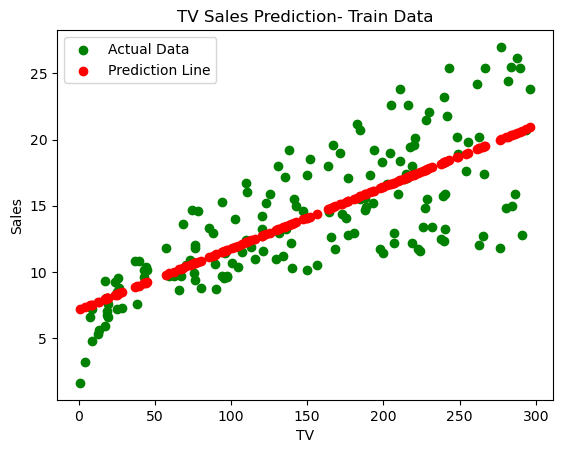

In [57]:
## Visuaize the results

plt.scatter(X_train, y_train, color = 'green', label = 'Actual Data')
plt.scatter(X_train, y_train_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Train Data')
plt.show()

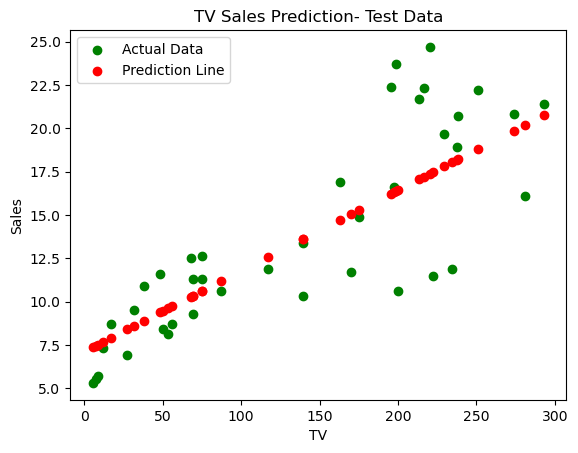

In [58]:
## Visuaize the results

plt.scatter(X_test, y_test, color = 'green', label = 'Actual Data')
plt.scatter(X_test, y_test_pred, color =  'red', label = 'Prediction Line')
plt.legend()
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV Sales Prediction- Test Data')
plt.show()

# __Date: 21-08-2025__

## Overfitting and UnderFitting 
When developing machine learning models, achieving the right balance between complexity and simplicity is crucial. This balance is covered in the concepts of overfitting and underfitting.

**Overfitting**
- Overfitting occurs when a model learns the noise and details in the training data too well to the extent that it negatively impacts its performance on new unseen data.
- Sign: High accuracy on training data but poor accuracy on test data.
- Cause: Model is too complex (too many parameters).

**Underfitting**
- Underfitting happens when a model is too simple to capture the underlying pattern of the data.
- Sign: Poor accuracy on both training and test data.
- Cause: Model is too simple (too few parameters).


  
**Bias-Variance Tradeoff**
- Bias: Error due to overly simplistic assumptions in the learning algorithm. High bias can cause underfitting.
- Variance: Error due to excessive complexity in the learning algorithm. High variance can cause overfitting.
**Tradeoff**
- Low Bias & High Variance: Model fits the training data very well but may fail to generalize (overfitting).
- High Bias & Low Variance: Model does not fit the training data well and misses the underlying trend (underfitting).
- Optimal Tradeoff: Finding a balance where the model performs well on both training and test data, minimizing overall error.
 
Understanding and managing the bias-variance tradeoff is key to building models that generalize well to unseen data.

In [59]:
## Let us calculate the errors made by the previous on train data and test data

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
mse_train =  mean_squared_error(y_train, y_train_pred)
mse_test=  mean_squared_error(y_test, y_test_pred)

print(f'Mean Sq. Error Train :  {mse_train:.4f}')
print(f'Mean Sq. Error Test :  {mse_test:.4f}')

Mean Sq. Error Train :  10.6036
Mean Sq. Error Test :  10.2047


In [62]:
r2_train =  r2_score(y_train, y_train_pred)
r2_test=  r2_score(y_test, y_test_pred)

print(f'R2 Score Train :  {r2_train:.4f}')
print(f'R2 Score  Test :  {r2_test:.4f}')

R2 Score Train :  0.5912
R2 Score  Test :  0.6767


In [63]:
# Check for overfitting or underfitting
if mse_train < mse_test or r2_train > r2_test:
    if abs(r2_train - r2_test) > 0.1:
        print("Model may be overfitting to the training data.")
    else:
        print("Model performs reasonably well but check for slight overfitting.")
elif mse_train > mse_test and r2_train < r2_test:
    print("Model may be underfitting, consider increasing model complexity.")
else:
    print("Model has a balanced fit on both training and testing datasets.")

Model may be underfitting, consider increasing model complexity.


**Observation**

 Mean Squared Error (MSE) and R-squared (R²) values are calculated for both training and test datasets.
 - MSE measures the average of the squares of the errors, that is, the average squared difference between the estimated values and the actual value.
 - R² provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model

Overfitting: The model performs well on the training data but poorly on the test data (higher R² on training or lower MSE on training compared to testing).

Underfitting: The model performs poorly on both training and test data, or better on the test data compared to the training data, which could suggest that the model is too simple.
We'll discuss more about MSE, R² and various other performance metrices, further in the lesson

## Non Linear Regression

**Polynomial Regression** is a subset of linear regression that includes polynomial terms.
The relationship between an independent variable (x) and a dependent variable (y) is modeled as an nth-degree polynomial.

- Polynomial regression is also called as the special case of multiple linear regression. Some polynomial terms are added to the multiple linear regression equation to convert into polynomial regression.
- It is a linear model with some modifications made to increase its accuracy.
- The dataset used in polynomial regression for training is non-linear

- it is seen that the straight line is unable to capture the patterns in the given data.
- To achieve a higher-order equation that captures complex data patterns, the powers of the original features can be added as new features.


- It provides the best approximation of the relationship between a dependent and an independent variable.
- It captures most data points and decreases the error between the actual and the predicted values.